In [2]:
# Plotting maps
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import rasterio


# general purpose
from itertools import cycle
import numpy as np
import pandas as pd


# Tristan's genomics utilities
import cairn as cn
from cairn.utils import prepare_discrete_colour_palette

In [3]:
# Import metadata as a pandas dataframe 
df_samples = pd.read_csv('/scratch/user/uqftolos/data/metadata/metadata-staged-cohorts-20260312.csv')
#species is stored as "taxon_pca" 

In [4]:
df_samples.groupby(
    ['taxon_pca','country','admin1_name','latitude','longitude']
).size().to_frame('count').to_csv('sample_locations.csv')

In [5]:
def plot_static_map(df, title, color, extent=[125, 171, -25, 0]):
    
    # Prepare colors
    color_data_unique_values = df[color].unique()

    # Get corresponding number of colours from Paired
    color_discrete_map = list(sns.color_palette("Paired",n_colors=len(color_data_unique_values)).as_hex())
    
    # Map values to colors.
    color_discrete_map_prepped = {
        v: c
        for v, c in zip(
            color_data_unique_values,
            cycle(color_discrete_map),
            strict=False
        )
    }
    
    # Create map with cartopy
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.OCEAN, color='lightblue')
    ax.add_feature(cfeature.LAND, color='lightgray')
    
    # Set extent [west, east, south, north]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # Plot points colored by factor
    for level in df[color].unique():
        data = df[df[color] == level]
        point_color = color_discrete_map_prepped.get(level, '#000000')  # Changed variable name
        ax.scatter(data['longitude'], data['latitude'], 
                   transform=ccrs.PlateCarree(), 
                   label=level, s=70, alpha=0.9, c=point_color,edgecolors='black', linewidths=0.5)

    
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
    plt.title(f'Species: {title}')
    plt.show()

def plot_interactive_map(df, title, color, color_discrete_map = None, extent=[125, 171, -25, 0]):
    """
    Create an interactive Plotly map with hover data.
    
    Parameters:
    -----------
    df : DataFrame
        Must contain columns: 'longitude', 'latitude', 'sample_id', 'admin1_iso', 
        and the column specified in 'color'
    title : str
        Title for the plot
    color : str
        Column name to use for coloring points
    extent : list
        Map bounds [west, east, south, north]
    """
    
    # Check for no color.
    if color is None:
        # Bail out early.
        return None, None, None

    # Now set up color choices.
    if color_discrete_map is None:
        color_discrete_map_prepped = prepare_discrete_colour_palette(df, color)
    
    else:
        color_discrete_map_prepped = color_discrete_map
    
    # Create interactive map
    fig = px.scatter_map(
        df,
        lat='latitude',
        lon='longitude',
        color=color,
        color_discrete_map=color_discrete_map_prepped,
        hover_data={
            'sample_id': True,
            'admin1_iso': True,
            'latitude': ':.4f',
            'longitude': ':.4f',
            color: True
        },
        title=f'Species: {title}',
        zoom=3,
        height=600,
        width=1000
    )
    
    # Calculate center from extent
    center_lat = (extent[2] + extent[3]) / 2
    center_lon = (extent[0] + extent[1]) / 2
    
    # Update map layout
    fig.update_layout(
        map=dict(
            style="basic",
            center=dict(lat=center_lat, lon=center_lon),
            zoom=3.5
        ),
        margin=dict(l=0, r=0, t=40, b=0)
    )

    # Update marker styling
    fig.update_traces(
        marker=dict(
            size=12,
            opacity=0.7,
            #line=dict(width=1, color='black')
        )
    )
    
    #fig.show()
    
    return fig


def plot_static_topo_map_hq(df, title, color, extent=[125, 171, -25, 0]):
    
    # Prepare colors
    color_data_unique_values = df[color].unique()
    color_discrete_map = list(sns.color_palette("Paired", n_colors=len(color_data_unique_values)).as_hex())
    
    color_discrete_map_prepped = {
        v: c
        for v, c in zip(
            color_data_unique_values,
            cycle(color_discrete_map),
            strict=False
        )
    }
    
    # Create map
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Set extent
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # Add high-resolution shaded relief from Natural Earth
    # This downloads once (~50MB), then it's cached forever
    ax.add_feature(cfeature.NaturalEarthFeature(
        'raster', 'shaded_relief', '10m',
        edgecolor='none'), zorder=0)
    
    # Overlay physical features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':', zorder=2)
    ax.add_feature(cfeature.LAKES, alpha=0.3, zorder=1)
    ax.add_feature(cfeature.RIVERS, linewidth=0.5, alpha=0.5, zorder=1)
    
    # Plot points
    for level in df[color].unique():
        data = df[df[color] == level]
        point_color = color_discrete_map_prepped.get(level, '#000000')
        ax.scatter(data['longitude'], data['latitude'], 
                   transform=ccrs.PlateCarree(), 
                   label=level, s=70, alpha=0.9, c=point_color,
                   edgecolors='black', linewidths=0.5, zorder=5)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='white', 
                      alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
    plt.title(f'Species: {title}')
    plt.show()

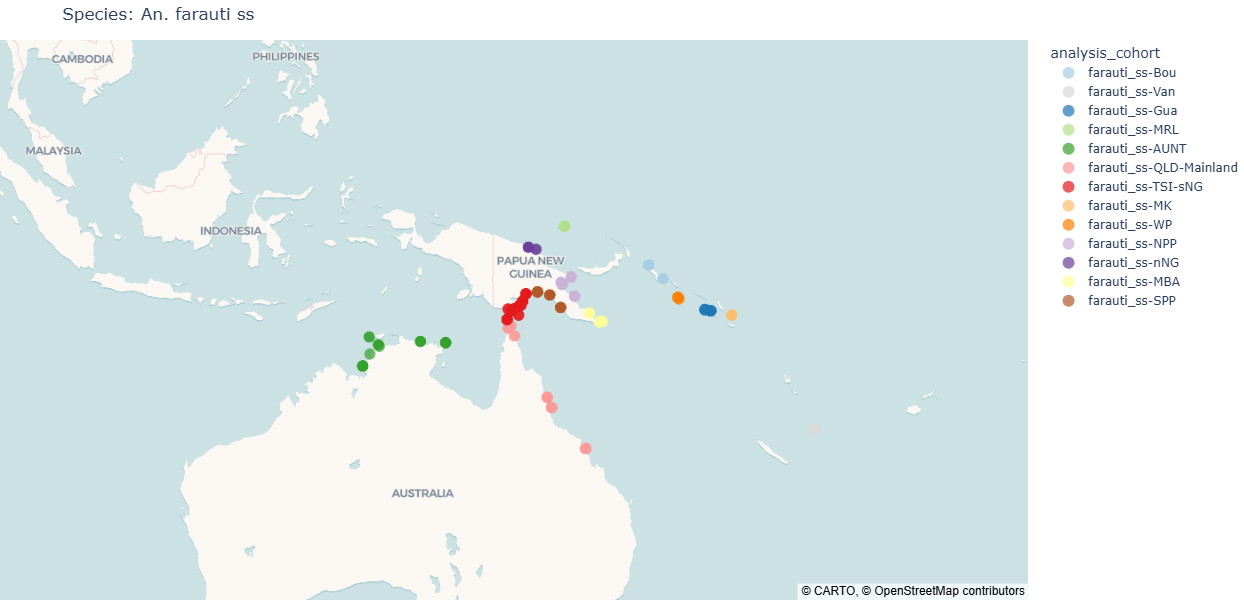

In [5]:
#An farauti ss
subset_df = df_samples.query('taxon_pca == "farauti_ss"')
color_data_unique_values = subset_df.analysis_cohort.unique()

# Make custom farauti pal
pal = list(sns.color_palette("Paired", n_colors=len(color_data_unique_values)-1).as_hex())#
pal.insert(1,"#d9d9d9") # add grey where vanuatu is
far_discrete_map_prepped = {
    v: c
    for v, c in zip(
        color_data_unique_values,
        cycle(pal),
        strict=False
    )
}


plot_interactive_map(subset_df, title = "An. farauti ss", color_discrete_map = far_discrete_map_prepped, color="analysis_cohort", extent=[125, 175, -13, -5])

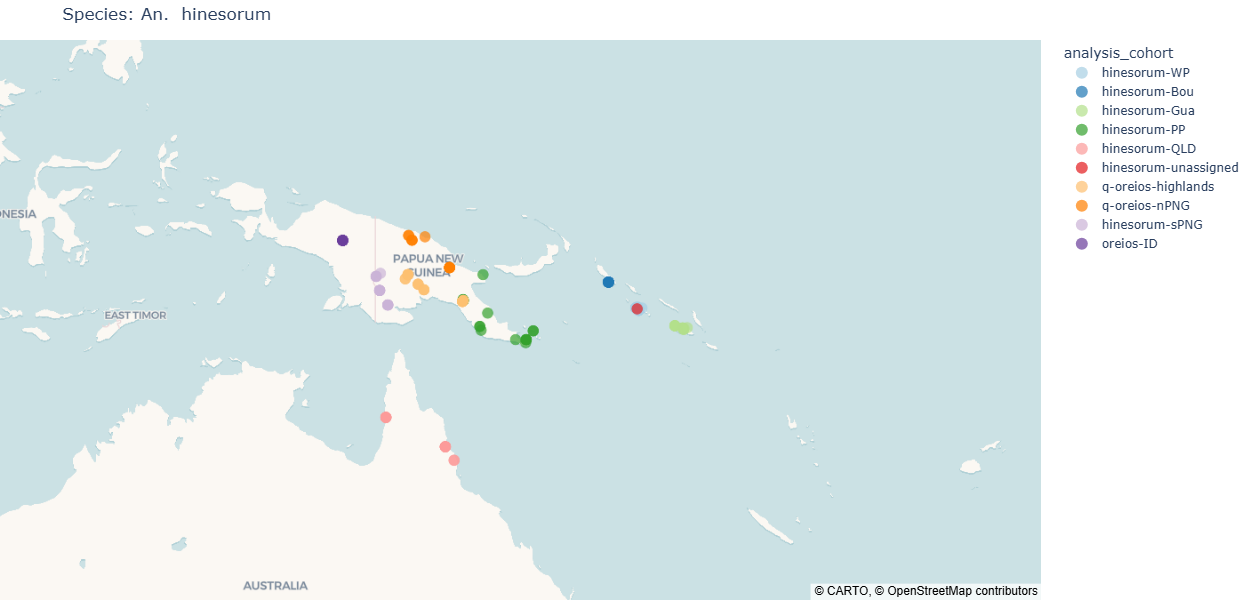

In [6]:
#An farauti ss
subset_df = df_samples.query('taxon_pca in ["hinesorum","oreios"]')
plot_interactive_map(subset_df, title = "An.  hinesorum", color="analysis_cohort", extent=[125, 175, -13, -5])

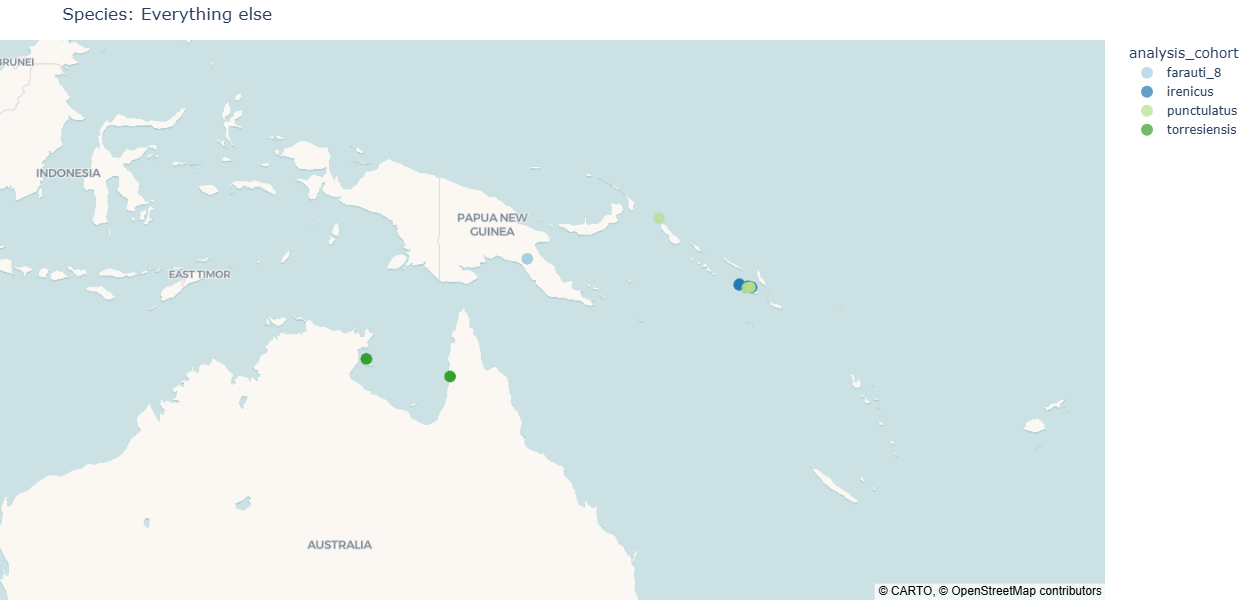

In [7]:
#Everything else
subset_df = df_samples.query('taxon_pca in ["punctulatus", "farauti_8", "irenicus", "torresiensis"]')
plot_interactive_map(subset_df, title = "Everything else", color="analysis_cohort", extent=[125, 171, -23, 0])

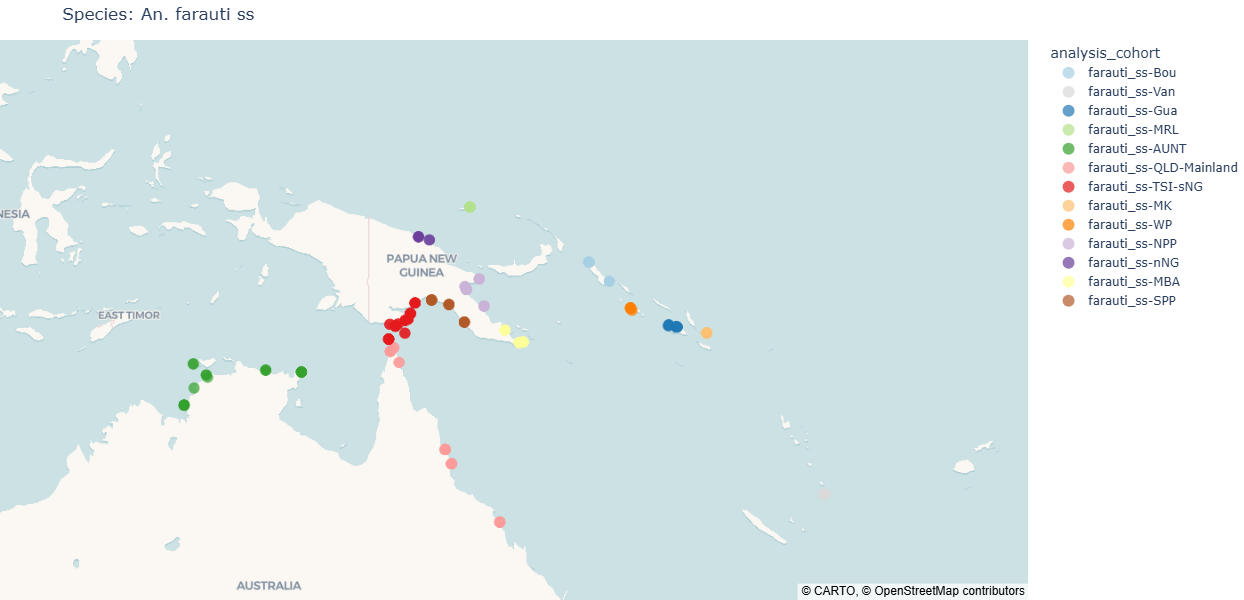

In [8]:
#An farauti ss
subset_df = df_samples.query('taxon_pca == "farauti_ss"')
color_data_unique_values = subset_df.analysis_cohort.unique()

# Make custom farauti pal
pal = list(sns.color_palette("Paired", n_colors=len(color_data_unique_values)-1).as_hex())#
pal.insert(1,"#d9d9d9") # add grey where vanuatu is
far_discrete_map_prepped = {
    v: c
    for v, c in zip(
        color_data_unique_values,
        cycle(pal),
        strict=False
    )
}


#plot_static_map(subset_df, title = "An. farauti ss", color="analysis_cohort", extent=[125, 171, -23, 0])
plot_interactive_map(subset_df, title = "An. farauti ss", color_discrete_map = far_discrete_map_prepped, color="analysis_cohort", extent=[125, 175, -13, -5])

## Plot a map for our paper
- Plot a map of our farauti ss samples from Australia and sPNG
- Load the dataframe
- Subset the dataframe to include only samples from Australia and sPNG
- Plot a map using the provided functions

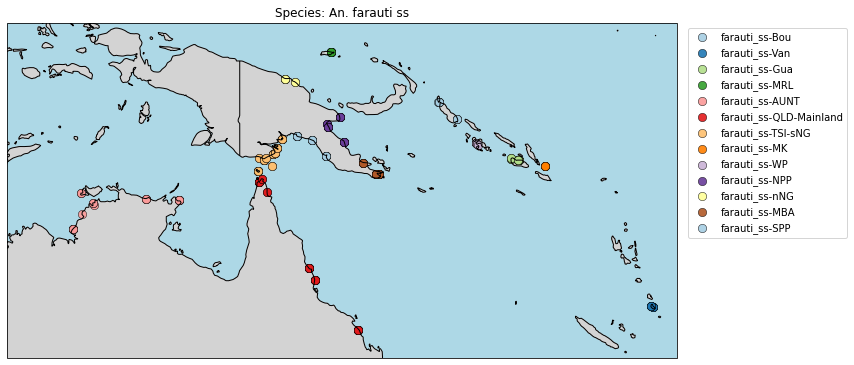

In [9]:
subset_df = df_samples.query('taxon_pca == "farauti_ss"') # modify me to select the samples we want to plot, aggregate and analyse
plot_static_map(subset_df, title = "An. farauti ss", color="analysis_cohort", extent=[125, 171, -23, 0])


## To Do (1wk)
- Use pandas to load the dataframe [x]
- Subset the dataframe using pandas.query to include sampels only from NT, QLD, TSI-sNG: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.query.html
- Generate grouped counts by country and sampling location (Table 1)



- Wants tables containing:
- counts of samples by country and cohort for farauti_ss
- counts of samples by sampling location
- map of samples for au-nt, qld, and tsi-sPNG
